# Bengaluru House Price Prediction

Data: `BHP.csv`, supplied as `BHP(2).xls` in CSV format. Price is assumed to be in INR lakh, following the original notebook. The collection date and original source documentation are unavailable.

Inputs: location, area type, floor area, bedrooms and bathrooms. Model selection uses five-fold grouped cross-validation on training data; 20% of input-description groups are held out for testing. The selection metric is MAE.

## Imports

### Basic libraries

In [1]:
import numpy as np
import pandas as pd
import sklearn

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
SEED = 42

## Load data

In [4]:
raw = pd.read_csv('BHP.csv')

## Inspect the data

In [5]:
print(raw.head().to_string(index=False))

           area_type  availability                 location      size society total_sqft  bath  balcony  price
Super built-up  Area        19-Dec Electronic City Phase II     2 BHK Coomee        1056   2.0      1.0  39.07
          Plot  Area Ready To Move         Chikka Tirupathi 4 Bedroom Theanmp       2600   5.0      3.0 120.00
      Built-up  Area Ready To Move              Uttarahalli     3 BHK     NaN       1440   2.0      3.0  62.00
Super built-up  Area Ready To Move       Lingadheeranahalli     3 BHK Soiewre       1521   3.0      1.0  95.00
Super built-up  Area Ready To Move                 Kothanur     2 BHK     NaN       1200   2.0      1.0  51.00


In [6]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [7]:
print(raw.describe(include='all').to_string())

                   area_type   availability    location   size  society total_sqft          bath       balcony         price
count                  13320          13320       13319  13304     7818      13320  13247.000000  12711.000000  13320.000000
unique                     4             81        1305     31     2688       2117           NaN           NaN           NaN
top     Super built-up  Area  Ready To Move  Whitefield  2 BHK  GrrvaGr       1200           NaN           NaN           NaN
freq                    8790          10581         540   5199       80        843           NaN           NaN           NaN
mean                     NaN            NaN         NaN    NaN      NaN        NaN      2.692610      1.584376    112.565627
std                      NaN            NaN         NaN    NaN      NaN        NaN      1.341458      0.817263    148.971674
min                      NaN            NaN         NaN    NaN      NaN        NaN      1.000000      0.000000      8.000000


## Data overview

In [8]:
print('Raw rows and columns:', raw.shape)
print('Exact duplicate source rows:', raw.duplicated().sum())

Raw rows and columns: (13320, 9)
Exact duplicate source rows: 529


In [9]:
print('Missing values:\n', raw.isna().sum().to_string())
print('Versions:', pd.__version__, np.__version__, sklearn.__version__)

Missing values:
 area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
Versions: 2.2.3 2.1.3 1.6.1


## Area conversion

### Convert areas to square feet

In [10]:
def parse_area(value):
    text = str(value).strip()

    if '-' in text:
        parts = text.split('-')
        try:
            low = float(parts[0])
            high = float(parts[1])
            return (low + high) / 2
        except ValueError:
            return np.nan

    units = {
        'Sq. Meter': 10.7639104,
        'Sq. Yards': 9,
        'Acres': 43560,
        'Guntha': 1089,
        'Grounds': 2400,
        'Perch': 272.25,
        'Cents': 435.6
    }

    for unit in units:
        if text.endswith(unit):
            number = text.replace(unit, '').strip()
            try:
                return float(number) * units[unit]
            except ValueError:
                return np.nan

    try:
        return float(text)
    except ValueError:
        return np.nan

## Data cleaning

In [11]:
df = raw.drop_duplicates().copy()

In [12]:
df['total_sqft'] = df['total_sqft'].map(parse_area)

### Extract bedrooms: “2 BHK” becomes 2

In [13]:
bedrooms = df['size'].str.split().str[0]
df['bhk'] = pd.to_numeric(bedrooms, errors='coerce')

### Convert bathrooms and price to numbers

In [14]:
df['bath'] = pd.to_numeric(df['bath'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

### Remove extra spaces from text

In [15]:
def clean_text(value):
    if isinstance(value, str):
        return value.strip()
    return np.nan

df['location'] = df['location'].apply(clean_text)
df['area_type'] = df['area_type'].apply(clean_text)
df['location'] = df['location'].replace('', np.nan)
df['area_type'] = df['area_type'].replace('', np.nan)

### Check valid prices, areas and bedroom counts

In [16]:
valid_price = df['price'].notna()
valid_price = valid_price & np.isfinite(df['price'])
valid_price = valid_price & (df['price'] > 0)

valid_area = df['total_sqft'].isna() | (df['total_sqft'] > 0)
valid_bhk = df['bhk'].isna() | (df['bhk'] > 0)

valid = valid_price & valid_area & valid_bhk
print('Rows excluded:', len(df) - valid.sum())

Rows excluded: 0


## Feature selection

### Keep the columns used in this model

In [17]:
features = ['location', 'area_type', 'total_sqft', 'bhk', 'bath']
columns = features + ['price']
df = df.loc[valid, columns]
df = df.drop_duplicates()
df = df.reset_index(drop=True)

### X contains inputs; y contains prices

In [18]:
X = df[features]
y = df['price']

## Duplicate groups

Each identical set of inputs gets the same group code. The hashing line is a pandas utility; its purpose is to keep repeated descriptions together.

In [19]:
groups = pd.util.hash_pandas_object(X, index=False).to_numpy()
print('Final records:', len(df), '| distinct input descriptions:', len(set(groups)))
print('Area values requiring imputation:', X['total_sqft'].isna().sum())

Final records: 12506 | distinct input descriptions: 10622
Area values requiring imputation: 0


In [20]:
assert 'price' not in X.columns and 'price_per_sqft' not in X.columns
assert parse_area('1000 - 1200') == 1100
assert parse_area('1Acres') == 43560

## Train–test split

### Reserve 20% of description groups for testing

In [21]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
for train_idx, test_idx in splitter.split(X, y, groups):
    break

### Create separate training and test variables

In [22]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
train_groups = groups[train_idx]
test_groups = groups[test_idx]

In [23]:
assert set(train_groups).isdisjoint(test_groups)
print('Train rows:', len(X_train), '| test rows:', len(X_test))

Train rows: 10051 | test rows: 2455


## Exploratory analysis

Distributions and relationships below use training records only. Price and floor-area axes use logarithmic scales where labelled to show the wide range without removing extreme listings.

In [24]:
import matplotlib.pyplot as plt

train_data = X_train.copy()
train_data['price'] = y_train
print(train_data.describe().to_string())

         total_sqft           bhk         bath         price
count  1.005100e+04  10036.000000  9991.000000  10051.000000
mean   1.969961e+03      2.825030     2.718747    116.799131
std    1.876171e+04      1.264704     1.321406    157.841482
min    1.000000e+00      1.000000     1.000000      8.000000
25%    1.100000e+03      2.000000     2.000000     50.000000
50%    1.296000e+03      3.000000     2.000000     74.820000
75%    1.700000e+03      3.000000     3.000000    125.000000
max    1.306800e+06     27.000000    27.000000   3600.000000


### Price distribution

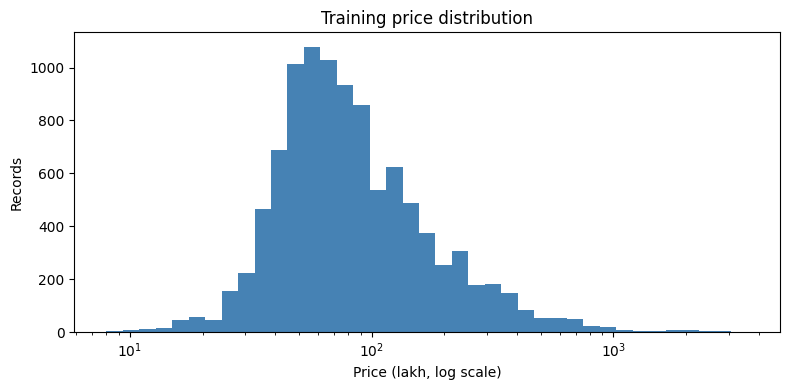

In [25]:
plt.figure(figsize=(8, 4))
price_bins = np.geomspace(y_train.min(), y_train.max(), 40)
plt.hist(y_train, bins=price_bins, color='steelblue')
plt.xscale('log')
plt.xlabel('Price (lakh, log scale)')
plt.ylabel('Records')
plt.title('Training price distribution')
plt.tight_layout()
plt.show()

### Area and price

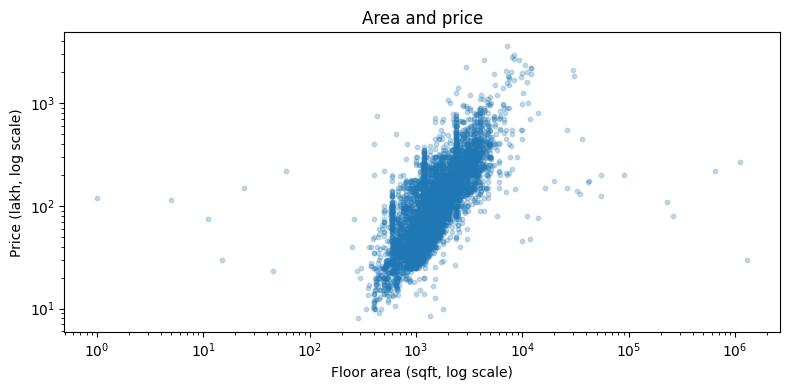

In [26]:
plt.figure(figsize=(8, 4))
plt.scatter(train_data['total_sqft'], train_data['price'], s=10, alpha=0.25)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Floor area (sqft, log scale)')
plt.ylabel('Price (lakh, log scale)')
plt.title('Area and price')
plt.tight_layout()
plt.show()

### Bedroom counts

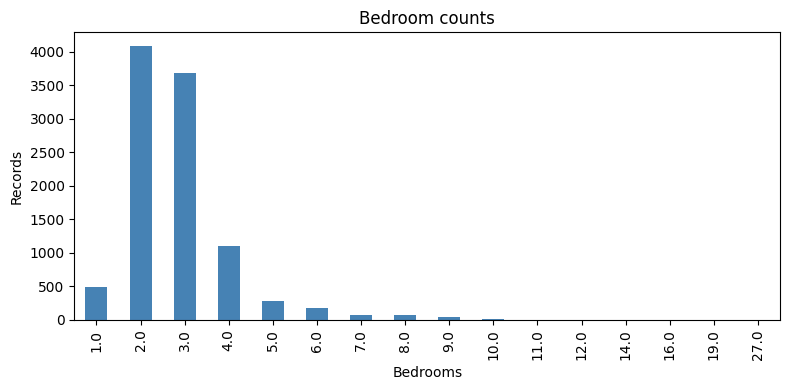

In [27]:
bedroom_counts = train_data['bhk'].value_counts().sort_index()
plt.figure(figsize=(8, 4))
bedroom_counts.plot.bar(color='steelblue')
plt.xlabel('Bedrooms')
plt.ylabel('Records')
plt.title('Bedroom counts')
plt.tight_layout()
plt.show()

### Most frequent locations

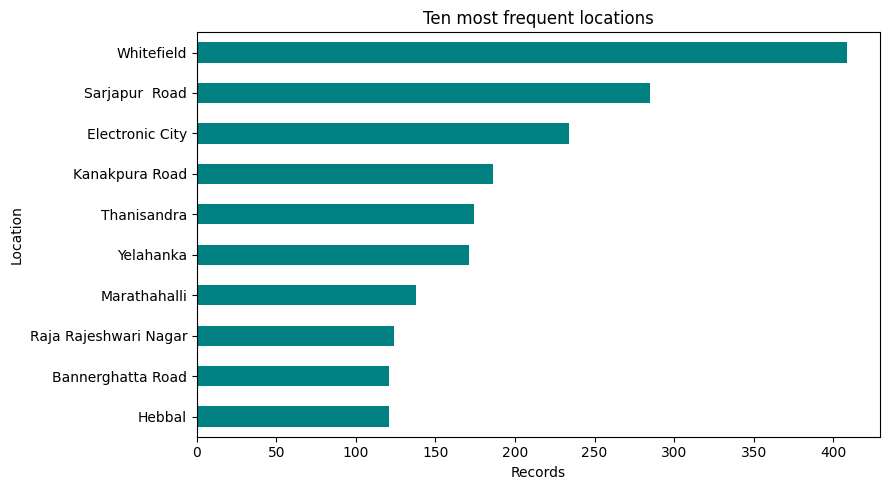

In [28]:
location_counts = train_data['location'].value_counts().head(10)
plt.figure(figsize=(9, 5))
location_counts.sort_values().plot.barh(color='teal')
plt.xlabel('Records')
plt.ylabel('Location')
plt.title('Ten most frequent locations')
plt.tight_layout()
plt.show()

### Numerical correlations

            total_sqft   bhk  bath  price
total_sqft        1.00  0.05  0.05   0.04
bhk               0.05  1.00  0.89   0.39
bath              0.05  0.89  1.00   0.45
price             0.04  0.39  0.45   1.00


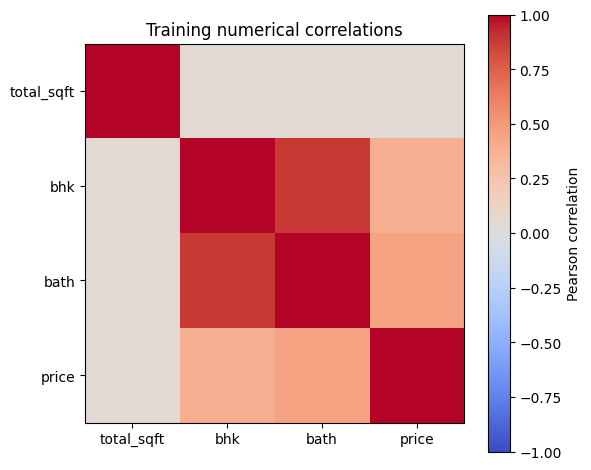

In [29]:
numeric_columns = ['total_sqft', 'bhk', 'bath', 'price']
correlation = train_data[numeric_columns].corr()
print(correlation.round(2))

plt.figure(figsize=(6, 5))
plt.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(4), numeric_columns)
plt.yticks(range(4), numeric_columns)
plt.colorbar(label='Pearson correlation')
plt.title('Training numerical correlations')
plt.tight_layout()
plt.show()

Correlation describes linear association and does not establish causation. The charts are descriptive; they are not used to choose additional filters or retune the model.

## Preprocessing

`Pipeline` runs steps in order. `ColumnTransformer` applies different steps to numbers and text. Keeping these inside the model search prevents validation data from affecting the learned cleaning rules.

### Fill missing numbers, then scale them

In [30]:
number_filler = SimpleImputer(strategy='median')
number_scaler = StandardScaler()

numeric_steps = [('fill', number_filler), ('scale', number_scaler)]
numeric = Pipeline(numeric_steps)

### Fill missing categories, then encode them

In [31]:
text_filler = SimpleImputer(strategy='most_frequent')
text_encoder = OneHotEncoder(
    handle_unknown='infrequent_if_exist',
    min_frequency=10
)

category_steps = [('fill', text_filler), ('encode', text_encoder)]
categorical = Pipeline(category_steps)

### Apply each preparation to its columns

In [32]:
numeric_columns = ['total_sqft', 'bhk', 'bath']
category_columns = ['location', 'area_type']

preparation_steps = [
    ('numbers', numeric, numeric_columns),
    ('categories', categorical, category_columns)
]
preprocess = ColumnTransformer(preparation_steps)

### Connect preparation and prediction

In [33]:
baseline_model = DummyRegressor(strategy='median')
model_steps = [('prepare', preprocess), ('model', baseline_model)]
pipeline = Pipeline(model_steps)

In [34]:
cv = GroupKFold(n_splits=5)

## Model comparison

### Create the five candidate models

In [35]:
baseline = DummyRegressor(strategy='median')
linear = LinearRegression()
lasso = Lasso(max_iter=20000)
tree = DecisionTreeRegressor(random_state=SEED)
forest = RandomForestRegressor(n_estimators=80, random_state=SEED, n_jobs=1)

### Choose the settings to compare

In [36]:
baseline_settings = {'model': [baseline]}
linear_settings = {'model': [linear]}
lasso_settings = {'model': [lasso], 'model__alpha': [0.1, 1.0]}

tree_settings = {
    'model': [tree],
    'model__max_depth': [8, 16],
    'model__min_samples_leaf': [5]
}

forest_settings = {
    'model': [forest],
    'model__max_depth': [16, None],
    'model__min_samples_leaf': [1, 3]
}

grid = [baseline_settings, linear_settings, lasso_settings, tree_settings, forest_settings]

`GridSearchCV` tries the settings using training folds. `refit="mae"` selects the lowest average absolute error and refits that choice on training data. The held-out test set is not used here.

In [37]:
search = GridSearchCV(pipeline, grid, cv=cv,
                      scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
                      refit='mae', n_jobs=1, error_score='raise')

In [38]:
search.fit(X_train, y_train, groups=train_groups)

GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             error_score='raise',
             estimator=Pipeline(steps=[('prepare',
                                        ColumnTransformer(transformers=[('numbers',
                                                                         Pipeline(steps=[('fill',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         ['total_sqft',
                                                                          'bhk',
                                                                          'bath']),
                                                                        ('categories',
                                                                         Pipeline(steps=[('fill',
                                                                                          SimpleImputer(strategy='m...
                         {'model': [Lasso(max_iter=20000)],
                          'model__alpha': [0.1, 1.0]},
                         {'model': [DecisionTreeRegressor(random_state=42)],
                          'model__max_depth': [8, 16],
                          'model__min_samples_leaf': [5]},
                         {'model': [RandomForestRegressor(n_estimators=80,
                                                          n_jobs=1,
                                                          random_state=42)],
                          'model__max_depth': [16, None],
                          'model__min_samples_leaf': [1, 3]}],
             refit='mae',
             scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

## Cross-validation results

### Make a model-comparison table

In [39]:
cv_results = pd.DataFrame(search.cv_results_)
model_names = []
for model in cv_results['param_model']:
    model_names.append(model.__class__.__name__)

comparison = pd.DataFrame()
comparison['model'] = model_names
comparison['CV_MAE_lakh'] = -cv_results['mean_test_mae']
comparison['CV_R2'] = cv_results['mean_test_r2']
comparison['CV_MAE_std'] = cv_results['std_test_mae']
comparison = comparison.sort_values('CV_MAE_lakh')

In [40]:
print(comparison.to_string(index=False))
print('Selected using training CV:', search.best_params_)

                model  CV_MAE_lakh     CV_R2  CV_MAE_std
RandomForestRegressor    38.100551  0.546461    1.488012
RandomForestRegressor    38.422638  0.543176    1.628789
RandomForestRegressor    38.928507  0.555574    1.271755
RandomForestRegressor    39.254149  0.554437    1.277403
DecisionTreeRegressor    41.459325  0.414656    1.591294
DecisionTreeRegressor    42.779309  0.396055    1.775845
                Lasso    56.948056  0.257352    1.118225
     LinearRegression    57.288411  0.262454    0.968597
                Lasso    58.405523  0.224377    1.618317
       DummyRegressor    66.812504 -0.074522    3.334513
Selected using training CV: {'model': RandomForestRegressor(n_estimators=80, n_jobs=1, random_state=42), 'model__max_depth': 16, 'model__min_samples_leaf': 1}


## Test evaluation

In [41]:
best_model = search.best_estimator_
prediction = best_model.predict(X_test)

In [42]:
baseline_prediction = np.repeat(y_train.median(), len(y_test))

### Measure the selected model

In [43]:
model_r2 = r2_score(y_test, prediction)
model_mae = mean_absolute_error(y_test, prediction)
model_rmse = np.sqrt(mean_squared_error(y_test, prediction))

print('Model R2:', round(model_r2, 4))
print('Model MAE (lakh):', round(model_mae, 2))
print('Model RMSE (lakh):', round(model_rmse, 2))

Model R2: 0.6456
Model MAE (lakh): 33.13
Model RMSE (lakh): 77.18


### Measure the baseline

In [44]:
baseline_r2 = r2_score(y_test, baseline_prediction)
baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction))

print('Baseline R2:', round(baseline_r2, 4))
print('Baseline MAE (lakh):', round(baseline_mae, 2))
print('Baseline RMSE (lakh):', round(baseline_rmse, 2))

Baseline R2: -0.0678
Baseline MAE (lakh): 59.66
Baseline RMSE (lakh): 133.96


In [45]:
errors = np.abs(y_test.to_numpy() - prediction)
print('Median absolute error (lakh):', round(float(np.median(errors)), 3))
print('90th percentile absolute error (lakh):', round(float(np.quantile(errors, .9)), 3))
print('Negative test predictions:', int((prediction < 0).sum()))
assert np.isfinite(prediction).all()

Median absolute error (lakh): 13.831
90th percentile absolute error (lakh): 72.858
Negative test predictions: 0


## Error analysis

In [46]:
residuals = X_test.copy()
residuals['actual_price_lakh'] = y_test
residuals['predicted_price_lakh'] = prediction
residuals['absolute_error_lakh'] = errors
print('Largest errors:\n', residuals.nlargest(5, 'absolute_error_lakh').to_string(index=False))

Largest errors:
                        location            area_type  total_sqft  bhk  bath  actual_price_lakh  predicted_price_lakh  absolute_error_lakh
                    Lakkasandra           Plot  Area      4500.0  9.0   9.0              166.0           1217.354167          1051.354167
           Jp nagar 8th Phase . Super built-up  Area     12000.0 10.0  12.0              525.0           1574.025000          1049.025000
                Sadashiva Nagar           Plot  Area      9600.0  5.0   7.0             2736.0           1862.248512           873.751488
                 Varsova Layout           Plot  Area      7000.0  6.0   6.0              560.0           1390.145833           830.145833
4 Bedroom Farm House in Bagalur           Plot  Area     10961.0  4.0   4.0               80.0            843.044643           763.044643


## Price prediction

### Predict one property

In [47]:
def predict_price(location, total_sqft, bhk, bath,
                  area_type='Super built-up  Area'):
    if total_sqft <= 0 or bhk <= 0 or bath <= 0:
        raise ValueError('Area, bedrooms and bathrooms must be positive.')

    property_details = {
        'location': [location.strip()],
        'area_type': [area_type.strip()],
        'total_sqft': [total_sqft],
        'bhk': [bhk],
        'bath': [bath]
    }
    new_property = pd.DataFrame(property_details)
    estimated_price = best_model.predict(new_property)
    return float(estimated_price[0])

In [48]:
example = predict_price('Whitefield', 1200, 2, 2)
print(f'Example: Whitefield, 1200 sqft, 2 BHK, 2 bathrooms: {example:.2f} lakh')

Example: Whitefield, 1200 sqft, 2 BHK, 2 bathrooms: 59.00 lakh


## Validation checks

In [49]:
assert np.isfinite(predict_price('UNSEEN_LOCATION_EXAMPLE', 1200, 2, 2))
assert np.isfinite(best_model.predict(pd.DataFrame([{
    'location': np.nan, 'area_type': np.nan, 'total_sqft': 1200,
    'bhk': 2, 'bath': np.nan}]))).all()
print('Checks passed: no shared input groups, finite predictions, missing-input and unseen-location handling.')

Checks passed: no shared input groups, finite predictions, missing-input and unseen-location handling.


## Findings

Random Forest had the lowest cross-validation MAE. On the held-out set, it achieved R² of 0.646, MAE of 33.11 lakh and RMSE of 77.14 lakh. The training-median baseline MAE was 59.66 lakh.

The model improves on the baseline, but large errors remain. These results describe this dataset and split, not current market performance. Actual price per square foot is excluded from the inputs because it is derived from the target. Preprocessing is fitted within each validation fold. No price-based outlier filtering is applied to the test set.

The original 0.9824 result is not reproduced. Features, retained records and evaluation differ, so the change cannot be attributed to a single cause.

## Limitations

Price units require source verification. Dataset age and property identities are unknown. Identical input descriptions do not necessarily identify the same property. Listing prices may differ from transaction prices, and age, condition and amenities are not included. Rare locations and unusual properties are less well supported. Validation on dated transaction data would be needed before operational use.